# Pathway Completion Risk & Early Intervention Analytics

Synthetic CampusEvolve dataset: student demographics, enrollments, aid, courses, interventions, and outcomes.

This notebook loads raw CSVs, explores distributions and equity gaps, engineers student-level features, trains dropout risk models, interprets drivers with SHAP, and exports Power BI–ready tables.


## Section 1 — Setup and Data Loading

Load all six CSVs from `data/raw/`, print shapes and dtypes, and coerce booleans (including string `True`/`False`) and numeric columns with missing values.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

BASE = Path.cwd().resolve()
if not (BASE / "data" / "raw").is_dir():
    BASE = BASE.parent
RAW = BASE / "data" / "raw"
assert RAW.is_dir(), f"Could not find data/raw; set cwd to project root or notebooks/. Tried {RAW}"

files = {
    "students": "students.csv",
    "enrollments": "enrollments.csv",
    "financial_aid": "financial_aid.csv",
    "courses": "courses.csv",
    "interventions": "interventions.csv",
    "outcomes": "outcomes.csv",
}

dfs = {name: pd.read_csv(RAW / fname) for name, fname in files.items()}
students, enrollments, financial_aid, courses, interventions, outcomes = (
    dfs["students"],
    dfs["enrollments"],
    dfs["financial_aid"],
    dfs["courses"],
    dfs["interventions"],
    dfs["outcomes"],
)

for name, df in dfs.items():
    print(f"\n=== {name} === shape={df.shape}")
    print(df.dtypes)


def to_bool(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series
    s = series.astype(str).str.strip().str.lower()
    is_na = series.isna()
    is_true = s.isin(["true", "1", "t", "yes"])
    is_false = s.isin(["false", "0", "f", "no"])
    out = np.where(
        is_na,
        np.nan,
        np.where(is_true, True, np.where(is_false, False, np.nan)),
    )
    return pd.Series(out, index=series.index)


bool_cols = {
    "students": ["first_gen_status"],
    "enrollments": ["withdrew"],
    "financial_aid": ["aid_gap_flag"],
    "courses": ["passed", "gateway_course"],
    "interventions": ["completed"],
    "outcomes": ["completed_program", "employed_within_6mo", "pathway_achieved"],
}

for key, cols in bool_cols.items():
    for c in cols:
        if c in dfs[key].columns:
            dfs[key][c] = to_bool(dfs[key][c])

# Numeric columns that may contain empty strings from CSV
for c in ["gpa_semester", "gpa_cumulative"]:
    if c in enrollments.columns:
        enrollments[c] = pd.to_numeric(enrollments[c], errors="coerce")
for c in ["pell_grant", "loans", "scholarships", "unmet_need"]:
    if c in financial_aid.columns:
        financial_aid[c] = pd.to_numeric(financial_aid[c], errors="coerce")
if "completion_year" in outcomes.columns:
    outcomes["completion_year"] = pd.to_numeric(outcomes["completion_year"], errors="coerce")
if "time_to_completion" in outcomes.columns:
    outcomes["time_to_completion"] = pd.to_numeric(outcomes["time_to_completion"], errors="coerce")

# Refresh references after in-place edits
students, enrollments, financial_aid, courses, interventions, outcomes = (
    dfs["students"],
    dfs["enrollments"],
    dfs["financial_aid"],
    dfs["courses"],
    dfs["interventions"],
    dfs["outcomes"],
)

print("\n--- After cleanup (sample dtypes) ---")
print(students.dtypes)
print(enrollments.dtypes)
print(outcomes.dtypes)



=== students === shape=(50000, 10)
student_id             str
age_at_enrollment    int64
gender                 str
race_ethnicity         str
first_gen_status      bool
income_bracket         str
state                  str
enrollment_year      int64
program_type           str
institution_type       str
dtype: object

=== enrollments === shape=(219443, 9)
enrollment_id            str
student_id               str
semester                 str
credits_attempted      int64
credits_completed      int64
gpa_semester         float64
gpa_cumulative       float64
enrollment_status        str
withdrew                bool
dtype: object

=== financial_aid === shape=(162400, 8)
aid_id              str
student_id          str
aid_year          int64
pell_grant      float64
loans           float64
scholarships    float64
unmet_need      float64
aid_gap_flag       bool
dtype: object

=== courses === shape=(841284, 8)
course_id          str
student_id         str
semester           str
course_name    

## Section 2 — Exploratory Data Analysis

Distributions of GPA and credits completed, withdrawal rates by semester (ordered), and completion rates by program and institution type. Uses Matplotlib and Seaborn.


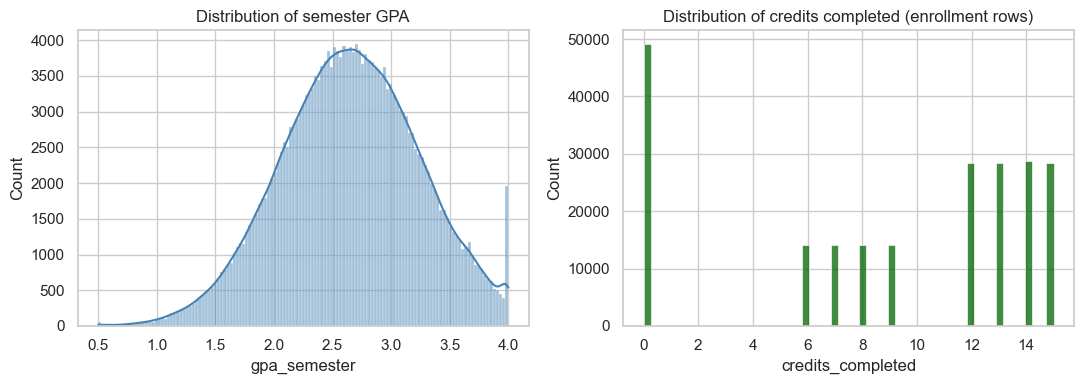

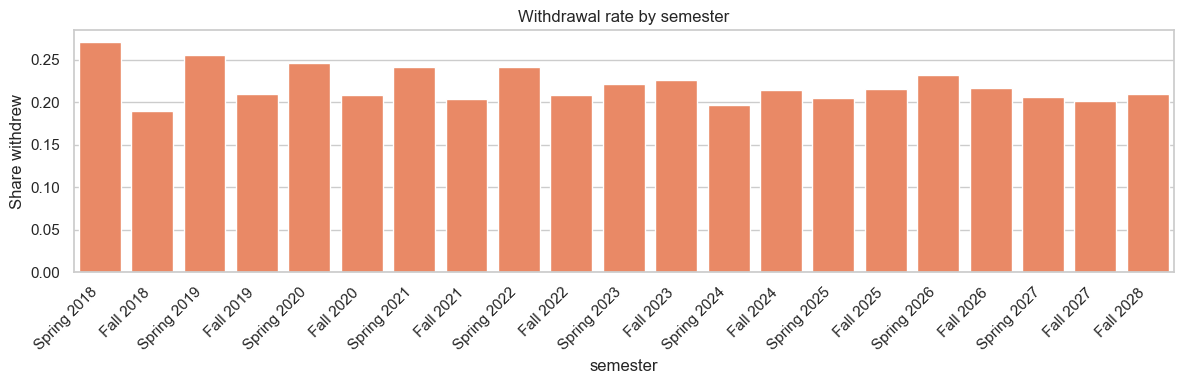

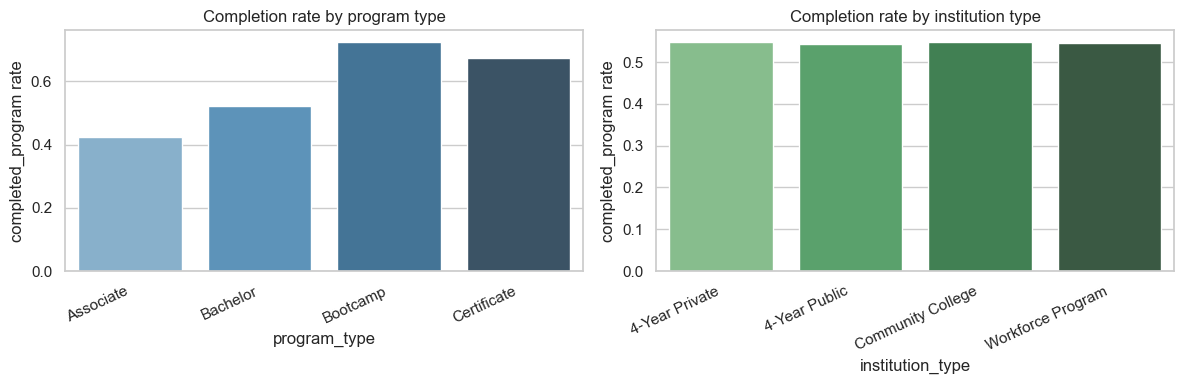

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(enrollments["gpa_semester"].dropna(), kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of semester GPA")
axes[0].set_xlabel("gpa_semester")

sns.histplot(enrollments["credits_completed"].dropna(), kde=False, ax=axes[1], color="darkgreen")
axes[1].set_title("Distribution of credits completed (enrollment rows)")
axes[1].set_xlabel("credits_completed")
plt.tight_layout()
plt.show()

# Withdrawal rate by semester (chronological order)
term_order = enrollments["semester"].map(
    lambda s: (
        2 * int(str(s).split()[1]) if str(s).startswith("Fall") else 2 * int(str(s).split()[1]) - 1
    )
)
tmp = enrollments.assign(_term=term_order)
sem_order = (
    tmp.groupby("semester", as_index=False)
    .agg(withdrawal_rate=("withdrew", "mean"), _t=("_term", "first"))
    .sort_values("_t")
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=sem_order, x="semester", y="withdrawal_rate", ax=ax, color="coral")
ax.set_title("Withdrawal rate by semester")
ax.set_ylabel("Share withdrew")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Completion rate by program type and institution type
comp = outcomes.merge(students[["student_id", "program_type", "institution_type"]], on="student_id", how="left")
by_prog = comp.groupby("program_type", as_index=False).agg(completion_rate=("completed_program", "mean"))
by_inst = comp.groupby("institution_type", as_index=False).agg(completion_rate=("completed_program", "mean"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=by_prog, x="program_type", y="completion_rate", ax=axes[0], palette="Blues_d")
axes[0].set_title("Completion rate by program type")
axes[0].set_ylabel("completed_program rate")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=25, ha="right")

sns.barplot(data=by_inst, x="institution_type", y="completion_rate", ax=axes[1], palette="Greens_d")
axes[1].set_title("Completion rate by institution type")
axes[1].set_ylabel("completed_program rate")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.show()


## Section 3 — Equity Disaggregation

Completion and employment rates by income bracket, first-generation status, and race/ethnicity (separately). Grouped bar charts show gap vs overall averages. Chi-square tests assess association; interpret p-values as exploratory rather than causal.


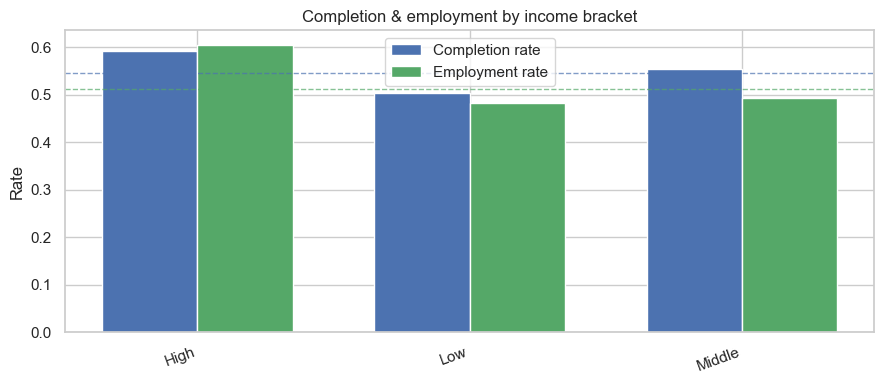

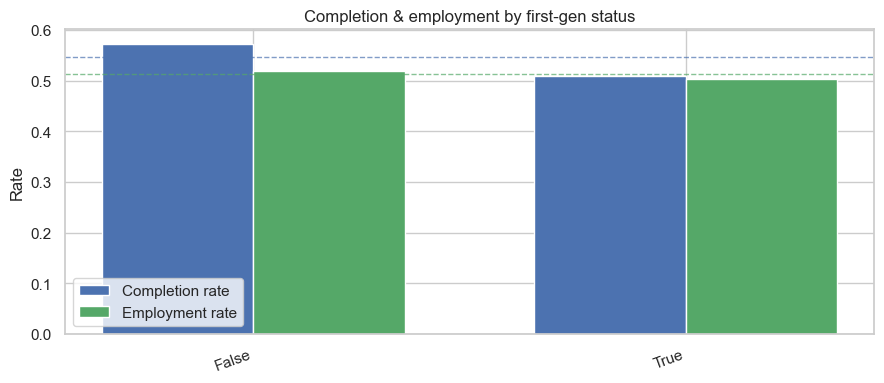

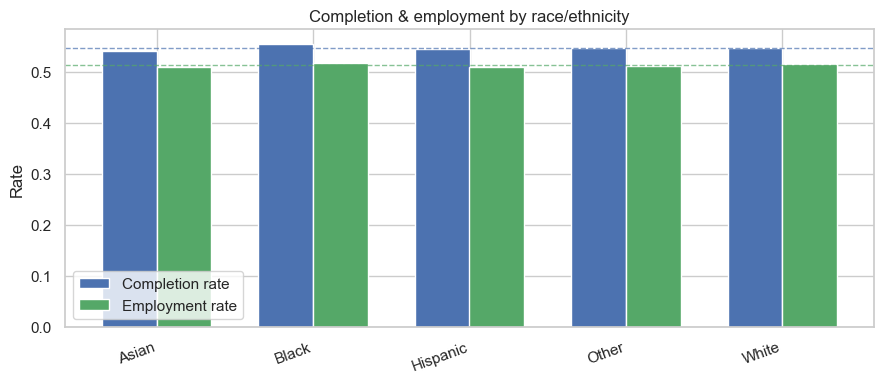

,income_bracket,n,completion_rate,employment_rate,completion_gap_vs_overall,employment_gap_vs_overall
0,High,9958,0.5928,0.6056,0.0462,0.0933
1,Low,15996,0.5047,0.4828,-0.0419,-0.0296
2,Middle,24046,0.5553,0.4934,0.0087,-0.0190


,first_gen_status,n,completion_rate,employment_rate,completion_gap_vs_overall,employment_gap_vs_overall
0,False,29466,0.5724,0.5182,0.0258,0.0058
1,True,20534,0.5095,0.5040,-0.0371,-0.0084


,race_ethnicity,n,completion_rate,employment_rate,completion_gap_vs_overall,employment_gap_vs_overall
0,Asian,4106,0.5409,0.5080,-0.0056,-0.0043
1,Black,5986,0.5548,0.5172,0.0082,0.0048
2,Hispanic,10060,0.5445,0.5083,-0.0020,-0.0041
3,Other,4015,0.5465,0.5111,-0.0001,-0.0013
4,White,25833,0.5464,0.5138,-0.0002,0.0014


Income: chi^2=206.39, p-value=1.52e-45
First-gen: chi^2=192.88, p-value=7.48e-44
Race/ethnicity: chi^2=2.34, p-value=6.74e-01
Note: Chi-square tests whether completion (binary) is independent of the demographic grouping. Small p-values suggest association; they do not imply causation. Multiple comparisons inflate Type I error unless adjusted (e.g., Bonferroni).


In [3]:
from scipy.stats import chi2_contingency
from IPython.display import display

m = outcomes.merge(
    students[["student_id", "income_bracket", "first_gen_status", "race_ethnicity"]],
    on="student_id",
    how="inner",
)

overall_c = m["completed_program"].mean()
overall_e = m["employed_within_6mo"].mean()


def equity_table(dim: str):
    g = (
        m.groupby(dim, dropna=False)
        .agg(
            n=("student_id", "count"),
            completion_rate=("completed_program", "mean"),
            employment_rate=("employed_within_6mo", "mean"),
        )
        .reset_index()
    )
    g["completion_gap_vs_overall"] = g["completion_rate"] - overall_c
    g["employment_gap_vs_overall"] = g["employment_rate"] - overall_e
    return g


def plot_equity(dim: str, title: str):
    g = equity_table(dim)
    fig, ax = plt.subplots(figsize=(9, 4))
    x = np.arange(len(g))
    w = 0.35
    ax.bar(x - w / 2, g["completion_rate"], width=w, label="Completion rate", color="#4C72B0")
    ax.bar(x + w / 2, g["employment_rate"], width=w, label="Employment rate", color="#55A868")
    ax.axhline(overall_c, color="#4C72B0", ls="--", lw=1, alpha=0.7)
    ax.axhline(overall_e, color="#55A868", ls="--", lw=1, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(g[dim].astype(str), rotation=20, ha="right")
    ax.set_ylabel("Rate")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return g


g_inc = plot_equity("income_bracket", "Completion & employment by income bracket")
g_fg = plot_equity("first_gen_status", "Completion & employment by first-gen status")
g_race = plot_equity("race_ethnicity", "Completion & employment by race/ethnicity")

display(g_inc.round(4))
display(g_fg.round(4))
display(g_race.round(4))

# Chi-square test: completed_program vs each dimension (independence)
for dim, label in [
    ("income_bracket", "Income"),
    ("first_gen_status", "First-gen"),
    ("race_ethnicity", "Race/ethnicity"),
]:
    ct = pd.crosstab(m[dim], m["completed_program"])
    chi2, p, _, _ = chi2_contingency(ct)
    print(f"{label}: chi^2={chi2:.2f}, p-value={p:.2e}")

print(
    "Note: Chi-square tests whether completion (binary) is independent of the demographic "
    "grouping. Small p-values suggest association; they do not imply causation. Multiple "
    "comparisons inflate Type I error unless adjusted (e.g., Bonferroni)."
)


## Section 4 — Feature Engineering (student level)

Build a student-level `model_df` with GPA mean, total credits attempted, withdrawal count, aid-gap and gateway-failure flags, intervention engagement score, and encoded demographics for modeling.


In [4]:
# Aggregates from enrollments
enr = enrollments.groupby("student_id").agg(
    gpa_mean=("gpa_semester", "mean"),
    credits_attempted_total=("credits_attempted", "sum"),
    total_withdrawals=("withdrew", lambda s: int(s.fillna(False).sum())),
)

# Aid gap ever
aid = financial_aid.groupby("student_id")["aid_gap_flag"].max().rename("aid_gap_ever")

# Gateway failure ever (gateway course with D or F)
gw_fail = (
    courses.assign(
        gateway_fail=lambda d: (d["gateway_course"].fillna(False)) & (d["grade"].isin(["D", "F"]))
    )
    .groupby("student_id")["gateway_fail"]
    .max()
    .rename("gateway_failure_ever")
)

# Intervention engagement: 0 if none; else completed / total
iv = interventions.groupby("student_id").agg(
    n_int=("intervention_id", "count"),
    n_done=("completed", lambda s: int(s.fillna(False).sum())),
)
iv["intervention_engagement_score"] = np.where(
    iv["n_int"] == 0, 0.0, iv["n_done"] / iv["n_int"]
)

base = students.merge(outcomes[["student_id", "completed_program"]], on="student_id", how="inner")
model_df = (
    base.merge(enr, on="student_id", how="left")
    .merge(aid, on="student_id", how="left")
    .merge(gw_fail, on="student_id", how="left")
    .merge(iv[["intervention_engagement_score", "n_int"]], on="student_id", how="left")
)

model_df["gpa_mean"] = model_df["gpa_mean"].fillna(model_df["gpa_mean"].median())
model_df["credits_attempted_total"] = model_df["credits_attempted_total"].fillna(0)
model_df["total_withdrawals"] = model_df["total_withdrawals"].fillna(0)
model_df["aid_gap_ever"] = model_df["aid_gap_ever"].fillna(False).astype(bool)
model_df["gateway_failure_ever"] = model_df["gateway_failure_ever"].fillna(False).astype(bool)
model_df["intervention_engagement_score"] = model_df["intervention_engagement_score"].fillna(0.0)

# Encoded categoricals for inspection (model pipeline will one-hot)
model_df["first_gen"] = model_df["first_gen_status"].astype(bool).astype(int)
model_df["income_encoded"] = model_df["income_bracket"].astype("category").cat.codes
model_df["program_encoded"] = model_df["program_type"].astype("category").cat.codes

feature_cols_display = [
    "gpa_mean",
    "credits_attempted_total",
    "total_withdrawals",
    "aid_gap_ever",
    "gateway_failure_ever",
    "intervention_engagement_score",
    "first_gen",
    "income_encoded",
    "program_encoded",
]
model_df[feature_cols_display].head(10)


,gpa_mean,credits_attempted_total,total_withdrawals,aid_gap_ever,gateway_failure_ever,intervention_engagement_score,first_gen,income_encoded,program_encoded
0,1.905500,14,0,True,False,0.000000,0,1,2
1,2.719125,105,0,False,False,0.000000,1,0,1
2,2.913375,108,1,True,True,0.666667,1,0,1
3,2.299154,100,4,True,True,0.000000,0,1,1
4,2.524500,54,1,True,True,1.000000,0,2,1
5,2.600125,106,1,True,True,0.500000,1,2,1
6,2.113000,14,1,True,False,0.000000,0,2,1
7,2.575000,30,0,True,False,0.000000,0,2,3
8,2.030000,29,1,True,False,0.000000,1,2,1
9,2.328714,51,2,True,True,0.000000,0,1,0


## Section 5 — Dropout Risk Model

Target: `completed_program`. Train/test split 80/20 with stratification. Logistic regression (baseline) and XGBoost with a preprocessing pipeline. Report ROC-AUC, precision–recall curve, confusion matrix, and XGBoost feature importances.


Logistic regression ROC-AUC: 0.9337


XGBoost ROC-AUC: 0.968


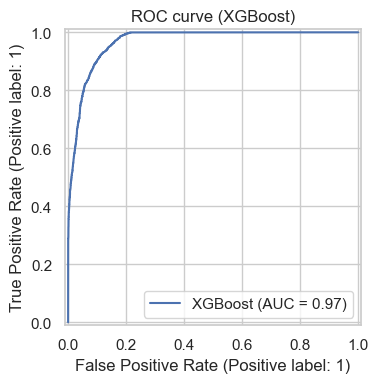

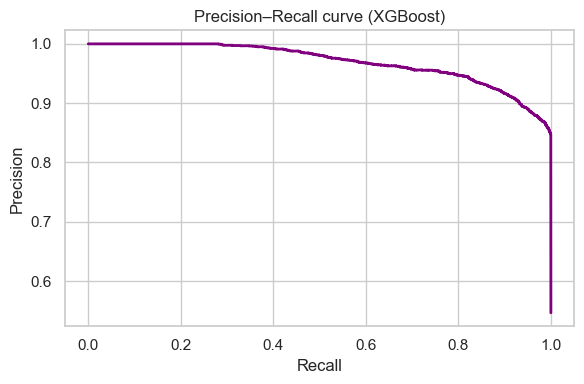

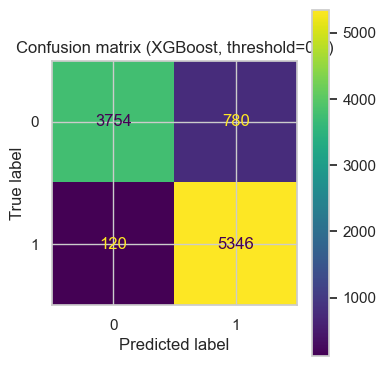


Top feature importances (XGBoost):
                           feature  importance
        cat__program_type_Bachelor    0.309796
       cat__program_type_Associate    0.203970
            num__total_withdrawals    0.147910
      num__credits_attempted_total    0.134331
     cat__program_type_Certificate    0.093820
        cat__program_type_Bootcamp    0.064574
                bool__aid_gap_ever    0.016907
        bool__gateway_failure_ever    0.009781
          cat__income_bracket_High    0.003997
                    num__first_gen    0.003810
           cat__income_bracket_Low    0.003733
                     num__gpa_mean    0.003199
num__intervention_engagement_score    0.002195
        cat__income_bracket_Middle    0.001978


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

y = model_df["completed_program"].astype(int)
X = model_df.drop(
    columns=[
        "completed_program",
        "student_id",
        "income_encoded",
        "program_encoded",
        "n_int",
    ],
    errors="ignore",
)

num_features = [
    "gpa_mean",
    "credits_attempted_total",
    "total_withdrawals",
    "intervention_engagement_score",
    "first_gen",
]
cat_features = ["income_bracket", "program_type"]
bool_features = ["aid_gap_ever", "gateway_failure_ever"]

X = X[num_features + bool_features + cat_features]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("bool", "passthrough", bool_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_pipe = Pipeline(
    steps=[
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced")),
    ]
)
log_pipe.fit(X_train, y_train)
y_proba_log = log_pipe.predict_proba(X_test)[:, 1]
print("Logistic regression ROC-AUC:", round(roc_auc_score(y_test, y_proba_log), 4))

xgb_pipe = Pipeline(
    steps=[
        ("prep", preprocess),
        (
            "clf",
            XGBClassifier(
                n_estimators=200,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=42,
                eval_metric="logloss",
            ),
        ),
    ]
)
xgb_pipe.fit(X_train, y_train)
y_proba_xgb = xgb_pipe.predict_proba(X_test)[:, 1]
print("XGBoost ROC-AUC:", round(roc_auc_score(y_test, y_proba_xgb), 4))

fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_xgb, ax=ax, name="XGBoost")
ax.set_title("ROC curve (XGBoost)")
plt.tight_layout()
plt.show()

# Precision–recall curve (XGBoost)
prec, rec, _ = precision_recall_curve(y_test, y_proba_xgb)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rec, prec, color="purple", lw=2)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall curve (XGBoost)")
plt.tight_layout()
plt.show()

# Confusion matrix @0.5 threshold
y_pred = (y_proba_xgb >= 0.5).astype(int)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
ax.set_title("Confusion matrix (XGBoost, threshold=0.5)")
plt.tight_layout()
plt.show()

# Feature importances (XGBoost on transformed space)
feat_names = xgb_pipe.named_steps["prep"].get_feature_names_out()
imp = xgb_pipe.named_steps["clf"].feature_importances_
imp_df = pd.DataFrame({"feature": feat_names, "importance": imp}).sort_values(
    "importance", ascending=False
)
print("\nTop feature importances (XGBoost):")
print(imp_df.head(15).to_string(index=False))


## Section 6 — SHAP Analysis

Explain the fitted XGBoost model with SHAP: summary plot, mean absolute SHAP bar chart, and top three drivers of dropout risk.


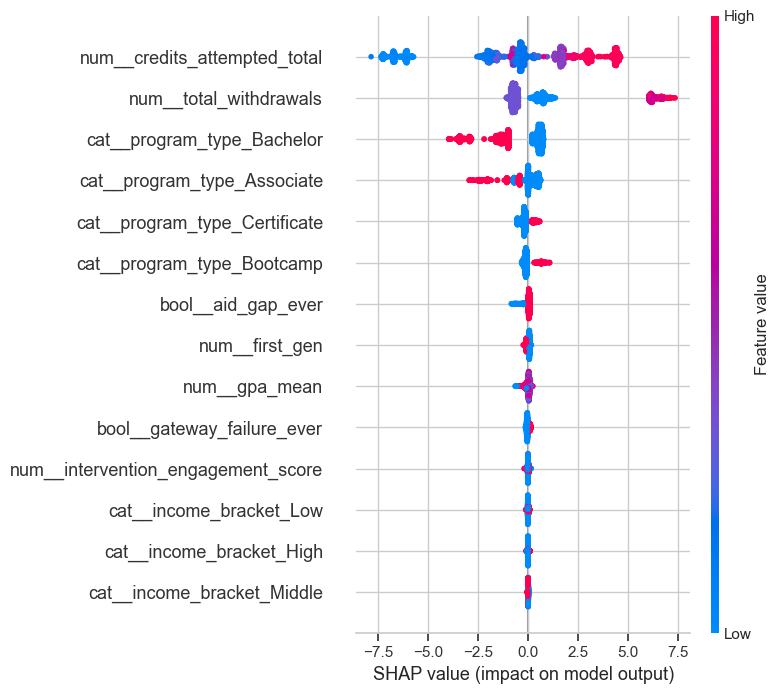

Top 3 drivers of dropout risk (by mean |SHAP|): ['num__credits_attempted_total', 'num__total_withdrawals', 'cat__program_type_Bachelor']


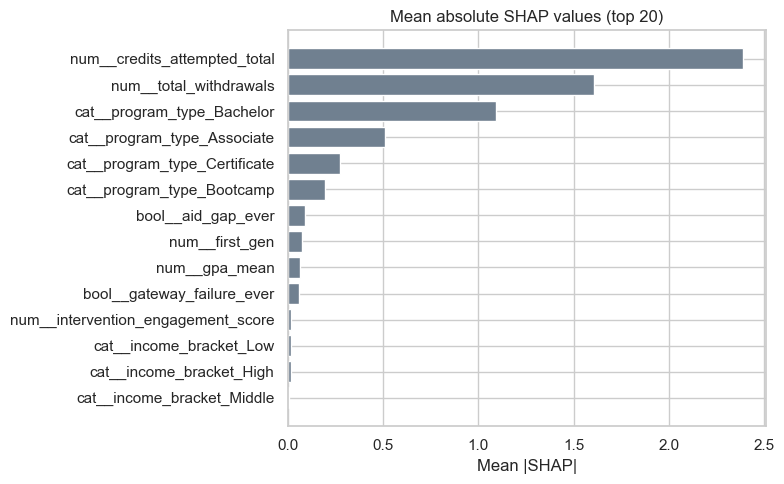

In [6]:
import shap

prep = xgb_pipe.named_steps["prep"]
clf = xgb_pipe.named_steps["clf"]
# Subsample test rows for tractable SHAP runtime on large cohorts
_shap_n = min(2000, len(X_test))
X_shap = X_test.sample(n=_shap_n, random_state=42) if len(X_test) > _shap_n else X_test
X_test_t = prep.transform(X_shap)
fnames = list(prep.get_feature_names_out())

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_t)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_test_t, feature_names=fnames, show=True)

mean_abs = np.abs(shap_values).mean(axis=0)
order = np.argsort(-mean_abs)
top3 = [fnames[i] for i in order[:3]]
print("Top 3 drivers of dropout risk (by mean |SHAP|):", top3)

fig, ax = plt.subplots(figsize=(8, 5))
idx = order[:20][::-1]
ax.barh([fnames[i] for i in idx], mean_abs[idx], color="slategray")
ax.set_xlabel("Mean |SHAP|")
ax.set_title("Mean absolute SHAP values (top 20)")
plt.tight_layout()
plt.show()


## Section 7 — Export for Power BI

Write three aggregated CSVs under `data/processed/powerbi_exports/` for dashboard consumption: completion funnel, at-risk monitoring, and equity gaps.


In [7]:
EXPORT = BASE / "data" / "processed" / "powerbi_exports"
EXPORT.mkdir(parents=True, exist_ok=True)

# --- dashboard_completion: funnel-style metrics by program, institution, cohort ---
comp_full = outcomes.merge(
    students[["student_id", "program_type", "institution_type", "enrollment_year"]],
    on="student_id",
    how="inner",
)
dash_comp = (
    comp_full.groupby(["program_type", "institution_type", "enrollment_year"], as_index=False)
    .agg(
        student_count=("student_id", "count"),
        completed_count=("completed_program", lambda s: int(s.sum())),
        employed_6mo_count=("employed_within_6mo", lambda s: int(s.sum())),
        pathway_count=("pathway_achieved", lambda s: int(s.sum())),
    )
)
dash_comp["completion_rate"] = dash_comp["completed_count"] / dash_comp["student_count"]
dash_comp["employment_rate"] = dash_comp["employed_6mo_count"] / dash_comp["student_count"]
dash_comp["pathway_rate"] = dash_comp["pathway_count"] / dash_comp["student_count"]
dash_comp.to_csv(EXPORT / "dashboard_completion.csv", index=False)

# --- dashboard_atrisk: risk tiers + intervention coverage ---
gpa_b = enrollments.groupby("student_id")["gpa_semester"].apply(lambda s: (s < 2.0).any())
wd = enrollments.groupby("student_id")["withdrew"].apply(lambda s: s.fillna(False).any())
ag = financial_aid.groupby("student_id")["aid_gap_flag"].apply(lambda s: s.fillna(False).any())
gw = (
    courses.assign(
        _gf=lambda d: d["gateway_course"].fillna(False) & d["grade"].isin(["D", "F"])
    )
    .groupby("student_id")["_gf"]
    .any()
)

risk_scores = students.merge(outcomes[["student_id", "completed_program"]], on="student_id", how="inner")
risk_scores = risk_scores.merge(gpa_b.rename("sig_gpa"), on="student_id", how="left")
risk_scores = risk_scores.merge(wd.rename("sig_wd"), on="student_id", how="left")
risk_scores = risk_scores.merge(ag.rename("sig_ag"), on="student_id", how="left")
risk_scores = risk_scores.merge(gw.rename("sig_gw"), on="student_id", how="left")
risk_scores["risk_score"] = (
    risk_scores["sig_gpa"].fillna(False).astype(int)
    + risk_scores["sig_wd"].fillna(False).astype(int)
    + risk_scores["sig_ag"].fillna(False).astype(int)
    + risk_scores["sig_gw"].fillna(False).astype(int)
).clip(upper=4)
risk_scores["risk_tier"] = pd.cut(
    risk_scores["risk_score"],
    bins=[-0.1, 1, 2, 4],
    labels=["Low", "Medium", "High"],
    include_lowest=True,
)

iv_cov = interventions.groupby("student_id").size().rename("intervention_count")
risk_scores = risk_scores.merge(iv_cov, on="student_id", how="left")
risk_scores["intervention_count"] = risk_scores["intervention_count"].fillna(0)
risk_scores["has_intervention"] = risk_scores["intervention_count"] > 0

dash_atrisk = (
    risk_scores.groupby("risk_tier", as_index=False)
    .agg(
        student_count=("student_id", "count"),
        pct_with_intervention=("has_intervention", "mean"),
        mean_interventions=("intervention_count", "mean"),
        completion_rate=("completed_program", "mean"),
    )
)
dash_atrisk.to_csv(EXPORT / "dashboard_atrisk.csv", index=False)

# --- dashboard_equity: one row per demographic slice ---
m2 = outcomes.merge(
    students[["student_id", "income_bracket", "first_gen_status", "race_ethnicity"]],
    on="student_id",
)
ov_c = m2["completed_program"].mean()
ov_e = m2["employed_within_6mo"].mean()

rows = []
for dim in ["income_bracket", "first_gen_status", "race_ethnicity"]:
    for val, sub in m2.groupby(dim):
        rows.append(
            {
                "dimension": dim,
                "category": val,
                "student_count": len(sub),
                "completion_rate": sub["completed_program"].mean(),
                "employment_rate": sub["employed_within_6mo"].mean(),
                "completion_gap_vs_overall": sub["completed_program"].mean() - ov_c,
                "employment_gap_vs_overall": sub["employed_within_6mo"].mean() - ov_e,
            }
        )
dash_equity = pd.DataFrame(rows)
dash_equity.to_csv(EXPORT / "dashboard_equity.csv", index=False)

print("Wrote:", EXPORT / "dashboard_completion.csv")
print("Wrote:", EXPORT / "dashboard_atrisk.csv")
print("Wrote:", EXPORT / "dashboard_equity.csv")


Wrote: /Users/ishanjoshi/Desktop/CampusEvolve/data/processed/powerbi_exports/dashboard_completion.csv
Wrote: /Users/ishanjoshi/Desktop/CampusEvolve/data/processed/powerbi_exports/dashboard_atrisk.csv
Wrote: /Users/ishanjoshi/Desktop/CampusEvolve/data/processed/powerbi_exports/dashboard_equity.csv
